# Going from smoothing to filtering

### Importing packages

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm

### Global parameters

In [49]:
np.random.seed(42)
n_obs = 1000

### Generating synthetic data

In [50]:
returns = []
current_state = 0
true_states = [] # <--- This list tracks the hidden state

for i in range(n_obs):
    true_states.append(current_state) # <--- Save the state for the plot
    if current_state == 0:
        returns.append(np.random.normal(0, 0.5)) 
        if np.random.rand() < 0.05: current_state = 1 
    else:
        returns.append(np.random.normal(0, 2.0)) 
        if np.random.rand() < 0.10: current_state = 0 

df = pd.DataFrame({'returns': returns, 'true_state': true_states})
print(df)

      returns  true_state
0    0.248357           0
1   -0.069132           0
2   -0.117077           0
3   -0.117068           0
4    0.789606           0
..        ...         ...
995 -0.337643           1
996  0.035026           0
997  0.580939           0
998 -0.463677           0
999  0.119184           0

[1000 rows x 2 columns]


### 70/30 split

In [51]:
split_idx = int(n_obs * 0.7)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

### Smoothing 

In [52]:
print("training on first 70% of data")
model = sm.tsa.MarkovRegression(train_df['returns'], k_regimes=2, trend='c', switching_variance=True)
res = model.fit(disp=False)

var_0, var_1 = res.params['sigma2[0]'], res.params['sigma2[1]']
mu_0, mu_1 = res.params['const[0]'], res.params['const[1]']

p00 = res.params['p[0->0]']
p10 = res.params['p[1->0]']
p01 = 1 - p00
p11 = 1 - p10

P = np.array([
    [p00, p01],
    [p10, p11]
])

print("\nLearned Transition Matrix (P):")
print(np.round(P, 3))

train_df['prob_state_1'] = res.smoothed_marginal_probabilities[1]

training on first 70% of data



Learned Transition Matrix (P):
[[0.95  0.05 ]
 [0.127 0.873]]


### Filtering

In [53]:
pi_t = np.array([
    res.smoothed_marginal_probabilities[0].iloc[-1],
    res.smoothed_marginal_probabilities[1].iloc[-1]
])

filtered_probs_state_1 = []

for y_next in test_df['returns']:

    pi_pred = P.T @ pi_t

    likelihood_0 = norm.pdf(y_next, loc=mu_0, scale=np.sqrt(var_0))
    likelihood_1 = norm.pdf(y_next, loc=mu_1, scale=np.sqrt(var_1))

    likelihoods = np.array([likelihood_0, likelihood_1])

    pi_unnormalized = pi_pred * likelihoods

    pi_t = pi_unnormalized / np.sum(pi_unnormalized)

    filtered_probs_state_1.append(pi_t[1])

test_df['prob_state_1'] = filtered_probs_state_1
print(test_df)

      returns  true_state  prob_state_1
700 -0.417674           0      0.719779
701  1.072575           0      0.799413
702  0.316888           0      0.414016
703  0.206900           0      0.144448
704  0.021906           0      0.047875
..        ...         ...           ...
995 -0.337643           1      0.320881
996  0.035026           0      0.101833
997  0.580939           0      0.065611
998 -0.463677           0      0.045211
999  0.119184           0      0.023388

[300 rows x 3 columns]


### Visualisation

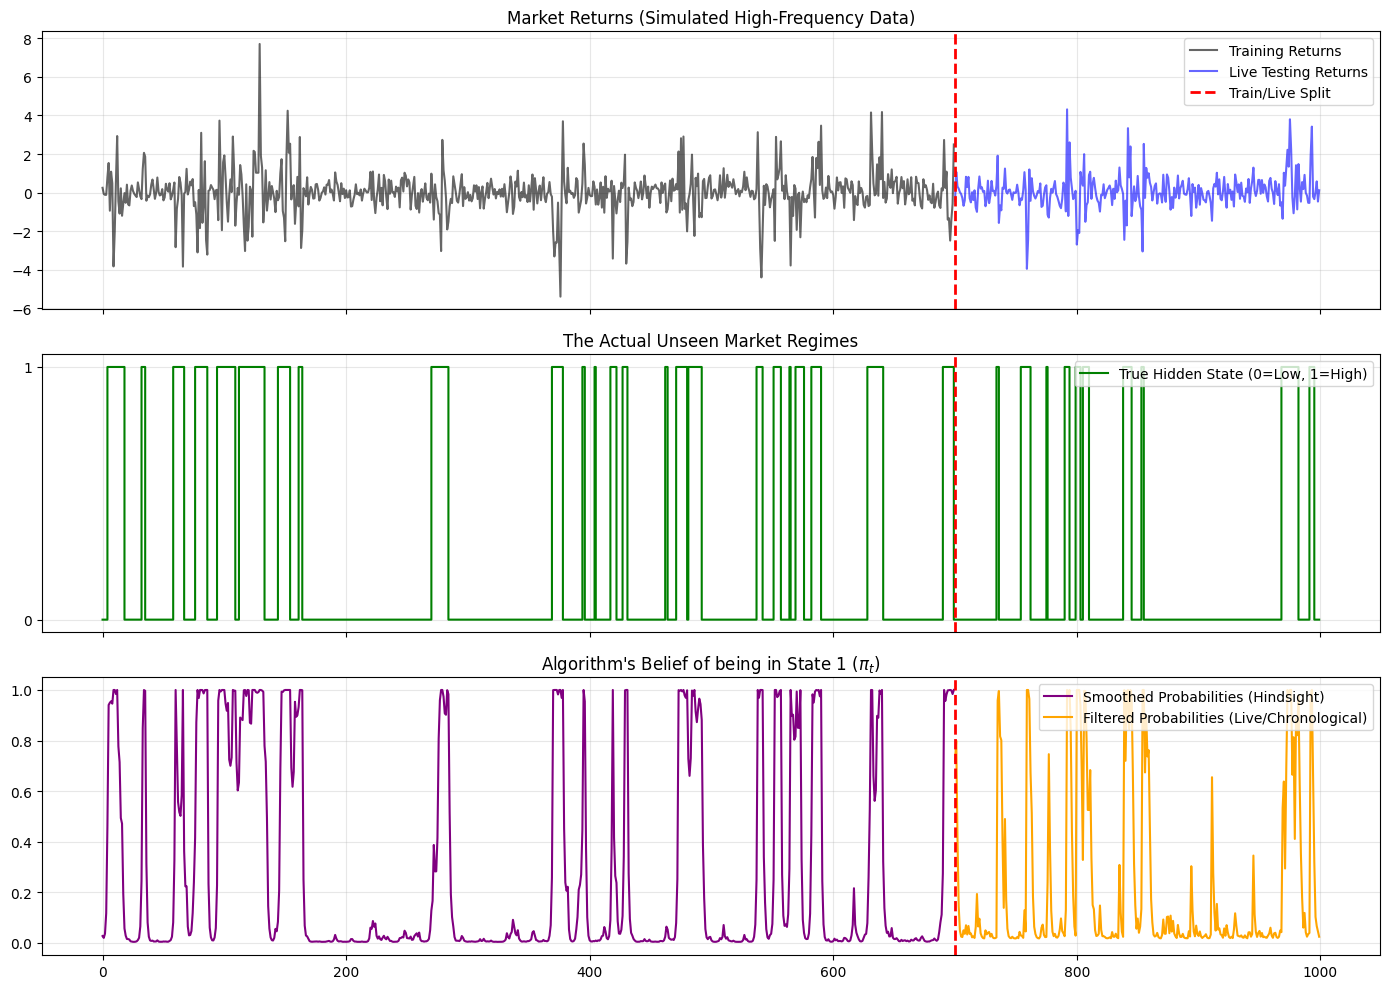

In [54]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(train_df.index, train_df['returns'], color='black', alpha=0.6, label='Training Returns')
axes[0].plot(test_df.index, test_df['returns'], color='blue', alpha=0.6, label='Live Testing Returns')
axes[0].axvline(x=split_idx, color='red', linestyle='--', linewidth=2, label='Train/Live Split')
axes[0].set_title('Market Returns (Simulated High-Frequency Data)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].step(df.index, df['true_state'], color='green', label='True Hidden State (0=Low, 1=High)')
axes[1].axvline(x=split_idx, color='red', linestyle='--', linewidth=2)
axes[1].set_title('The Actual Unseen Market Regimes')
axes[1].set_yticks([0, 1])
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

axes[2].plot(train_df.index, train_df['prob_state_1'], color='purple', label='Smoothed Probabilities (Hindsight)')
axes[2].plot(test_df.index, test_df['prob_state_1'], color='orange', label='Filtered Probabilities (Live/Chronological)')
axes[2].axvline(x=split_idx, color='red', linestyle='--', linewidth=2)
axes[2].set_title('Algorithm\'s Belief of being in State 1 ($\pi_t$)')
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Summary statistics

In [55]:
print("--- Model Evaluation Metrics ---")
# Log-Likelihood is specifically mentioned by your supervisor as important 
# when you start cutting days into chunks.
print(f"Log-Likelihood (LLF): {res.llf:.4f}")

# AIC and BIC
print(f"AIC (Akaike Information Criterion): {res.aic:.4f}")
print(f"BIC (Bayesian Information Criterion): {res.bic:.4f}")
print(f"HQIC (Hannan-Quinn Information Criterion): {res.hqic:.4f}")

print("\n--- Learned State Parameters ---")
print(f"State 0 Variance (Low):  {var_0:.4f}")
print(f"State 1 Variance (High): {var_1:.4f}")

print("\n--- Learned Transition Matrix ---")
print(f"P(Stay in Low Vol):  {P[0,0]:.4f} | P(Switch to High): {P[0,1]:.4f}")
print(f"P(Switch to Low):    {P[1,0]:.4f} | P(Stay in High Vol): {P[1,1]:.4f}")

--- Model Evaluation Metrics ---
Log-Likelihood (LLF): -850.0675
AIC (Akaike Information Criterion): 1712.1350
BIC (Bayesian Information Criterion): 1739.4415
HQIC (Hannan-Quinn Information Criterion): 1722.6906

--- Learned State Parameters ---
State 0 Variance (Low):  0.2311
State 1 Variance (High): 3.7563

--- Learned Transition Matrix ---
P(Stay in Low Vol):  0.9503 | P(Switch to High): 0.0497
P(Switch to Low):    0.1273 | P(Stay in High Vol): 0.8727


### True versus learned comparison

In [56]:
true_var_0 = 0.5**2
true_var_1 = 2.0**2
true_p00 = 0.95
true_p01 = 0.05
true_p10 = 0.10
true_p11 = 0.90

print("--- Parameter Comparison (True vs Learned) ---")
print(f"State 0 Variance:  True = {true_var_0:.4f} | Learned = {var_0:.4f}")
print(f"State 1 Variance:  True = {true_var_1:.4f} | Learned = {var_1:.4f}")
print("-" * 45)
print(f"P(0->0) Stay Low:  True = {true_p00:.4f} | Learned = {P[0,0]:.4f}")
print(f"P(0->1) Switch Hi: True = {true_p01:.4f} | Learned = {P[0,1]:.4f}")
print(f"P(1->0) Switch Lo: True = {true_p10:.4f} | Learned = {P[1,0]:.4f}")
print(f"P(1->1) Stay High: True = {true_p11:.4f} | Learned = {P[1,1]:.4f}")

--- Parameter Comparison (True vs Learned) ---
State 0 Variance:  True = 0.2500 | Learned = 0.2311
State 1 Variance:  True = 4.0000 | Learned = 3.7563
---------------------------------------------
P(0->0) Stay Low:  True = 0.9500 | Learned = 0.9503
P(0->1) Switch Hi: True = 0.0500 | Learned = 0.0497
P(1->0) Switch Lo: True = 0.1000 | Learned = 0.1273
P(1->1) Stay High: True = 0.9000 | Learned = 0.8727
